# <font color="#418FDE" size="6.5" uppercase>**TensorFlow Sequential & Convolutional Models**</font>

>Last update: 20260327.
    
By the end of this Lecture, you will be able to:
- Train TensorFlow Sequential models for CE prediction and classification tasks. 
- Construct convolutional neural networks using one- and two-dimensional convolution, pooling, padding, and more layers. 
- Apply methods such as Dropout, BatchNormalization, one-hot encoding, and more in TensorFlow models. 


## **1. Sequential Model Basics**

### **1.1. Sequential Model Structure**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_01_01.jpg?v=1774648207" width="250">



>* Sequential models pass data through ordered layers.
>* Useful for civil engineering prediction tasks.

>* Input shape and dense layers define structure.
>* Layer size controls complexity and overfitting.

>* Prepared tabular data supports consistent Sequential learning.
>* Sequential models clearly map inputs to predictions.



TensorFlow version: 2.21.0
Input shape expected: (None, 8)
Output shape produced: (None, 1)
Train samples: 721 Test samples: 155
Test MAE: 5.889
Test R2: 0.793


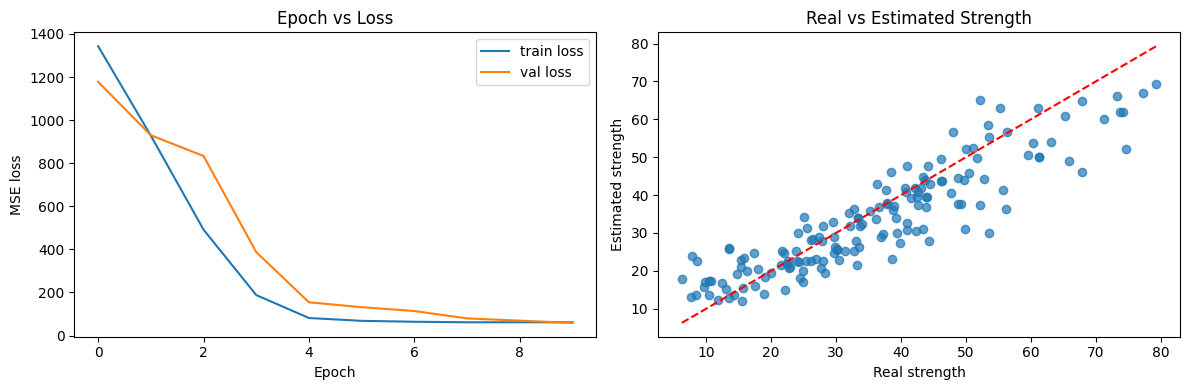

In [15]:
#@title Python Code - Sequential Model Structure

# Sequential models pass data layer by layer.
# This example predicts concrete compressive strength.
# We build and inspect model structure.

# !pip install tensorflow==2.20.0 scikit-learn==1.8.0 xlrd

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import ReLU, Dropout, Input

# Set seeds for reproducible results.
np.random.seed(7)
tf.random.set_seed(7)
print("TensorFlow version:", tf.__version__)

# Download the concrete dataset file.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Load the spreadsheet into pandas.
df = pd.read_excel("./Concrete_Data.xls")

# Keep column names short and readable.
df.columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age", "strength"
]

# Split features and target values.
X = df.drop("strength", axis=1).astype("float32").to_numpy()
y = df["strength"].astype("float32").to_numpy().reshape(-1, 1)

# Check basic input and output shapes.
input_features = X.shape[1]
output_units = y.shape[1]

# Create deterministic shuffled indices.
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Make train validation test splits.
n_total = len(X)
n_train = int(0.7 * n_total)
n_val = int(0.15 * n_total)

X_train = X[:n_train]
y_train = y[:n_train]
X_val = X[n_train:n_train + n_val]
y_val = y[n_train:n_train + n_val]
X_test = X[n_train + n_val:]
y_test = y[n_train + n_val:]

# Standardize features using training statistics.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)
train_std[train_std == 0] = 1.0

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Build a reusable hidden block.
def dense_block(units, drop_rate):
    block = []
    block.append(Dense(units))
    block.append(BatchNormalization())
    block.append(ReLU())
    block.append(Dropout(drop_rate))
    return block

# Build the Sequential model step by step.
model = Sequential(name="concrete_strength_model")
model.add(Input(shape=(input_features,), name="input_layer"))

# Add hidden layers from reusable blocks.
for layer in dense_block(64, 0.10):
    model.add(layer)
for layer in dense_block(32, 0.10):
    model.add(layer)

# Add one regression output unit.
model.add(Dense(output_units, name="output_layer"))

# Compile the model for regression.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Train quietly with validation data.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=0
)

# Predict strengths for the test set.
y_pred = model.predict(X_test, verbose=0).reshape(-1)
y_true = y_test.reshape(-1)

# Compute simple evaluation metrics.
mae_value = mean_absolute_error(y_true, y_pred)
r2_value = r2_score(y_true, y_pred)

# Print a few key teaching results.
print("Input shape expected:", model.input_shape)
print("Output shape produced:", model.output_shape)
print("Train samples:", len(X_train), "Test samples:", len(X_test))
print("Test MAE:", round(float(mae_value), 3))
print("Test R2:", round(float(r2_value), 3))

# Create one figure with two teaching plots.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot training and validation loss.
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Epoch vs Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()

# Plot real versus estimated strengths.
axes[1].scatter(y_true, y_pred, alpha=0.7)
line_min = float(min(y_true.min(), y_pred.min()))
line_max = float(max(y_true.max(), y_pred.max()))
axes[1].plot([line_min, line_max], [line_min, line_max], "r--")
axes[1].set_title("Real vs Estimated Strength")
axes[1].set_xlabel("Real strength")
axes[1].set_ylabel("Estimated strength")

# Show the final teaching figure.
plt.tight_layout()
plt.show()



### **1.2. Activations and Compilation**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_01_02.jpg?v=1774648242" width="250">



>* Activations enable learning complex nonlinear patterns.
>* Match output activation to the task.

>* Compilation sets loss, optimizer, and metrics.
>* Choices must match prediction task goals.

>* Match outputs and losses to tasks.
>* Alignment improves stability, interpretation, and decisions.



TensorFlow version: 2.21.0
Training device: CPU
Activation comparison:
activation  accuracy  precision  recall
      tanh    0.9135     0.9135  0.9125
      relu    0.9115     0.9137  0.9104
   sigmoid    0.8915     0.8907  0.8909
    linear    0.8840     0.8835  0.8825
Best hidden activation: tanh


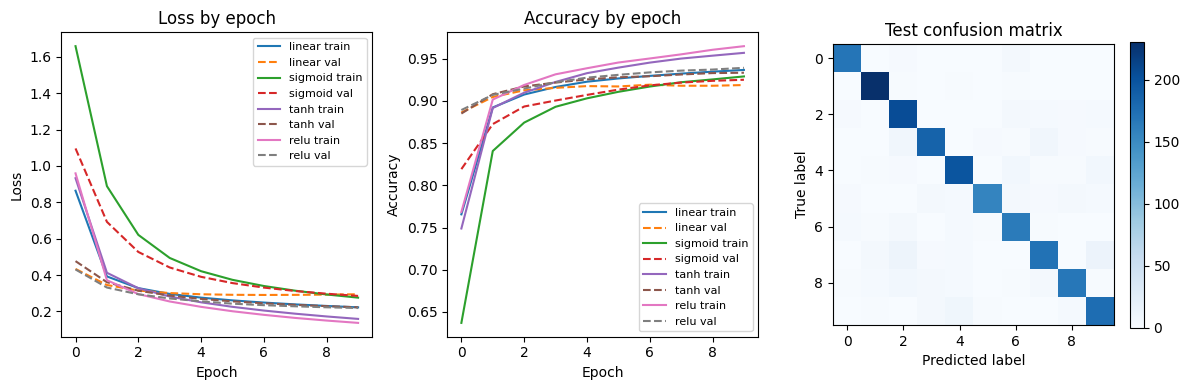

In [16]:
#@title Python Code - Activations and Compilation

# Compare activations in a simple classifier.
# MNIST images support beginner TensorFlow practice.
# Compilation choices affect learning and accuracy.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR');
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Detect available training device.
gpus = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpus) > 0 else "CPU"
print("Training device:", device_name)

# Load the MNIST image dataset.
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.mnist.load_data()
)

# Keep a small subset for speed.
train_images = train_images[:12000]
train_labels = train_labels[:12000]
test_images = test_images[:2000]
test_labels = test_labels[:2000]

# Normalize pixel values safely.
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Validate image shapes before training.
assert train_images.shape[1:] == (28, 28)
assert test_images.shape[1:] == (28, 28)

# Prepare one hot encoded labels.
train_targets = tf.keras.utils.to_categorical(train_labels, 10)
test_targets = tf.keras.utils.to_categorical(test_labels, 10)

# Build a small Sequential model.
def build_model(hidden_activation):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(64, activation=hidden_activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    # Compile with Adam and classification loss.
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Train one model for each activation.
activations = ["linear", "sigmoid", "tanh", "relu"]
histories = {}
results = []
last_model = None

# Loop through activation choices.
for activation_name in activations:
    model = build_model(activation_name)

    # Train quietly with validation split.
    history = model.fit(
        train_images,
        train_targets,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )

    # Predict test classes quietly.
    probabilities = model.predict(test_images, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)

    # Store metrics for comparison.
    acc = accuracy_score(test_labels, predicted_labels)
    prec = precision_score(
        test_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )
    rec = recall_score(
        test_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    # Save history and summary row.
    histories[activation_name] = history.history
    results.append([activation_name, acc, prec, rec])
    last_model = model

# Create a small results table.
results_df = pd.DataFrame(
    results,
    columns=["activation", "accuracy", "precision", "recall"]
)
results_df = results_df.sort_values("accuracy", ascending=False)

# Print a short comparison summary.
print("Activation comparison:")
print(results_df.round(4).to_string(index=False))

# Select the best activation name.
best_activation = results_df.iloc[0]["activation"]
print("Best hidden activation:", best_activation)

# Predict again using the best model.
best_probabilities = last_model.predict(test_images, verbose=0)
best_predictions = np.argmax(best_probabilities, axis=1)

# Build the confusion matrix.
cm = confusion_matrix(test_labels, best_predictions)

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot loss curves for all activations.
for activation_name in activations:
    axes[0].plot(
        histories[activation_name]["loss"],
        label=activation_name + " train"
    )
    axes[0].plot(
        histories[activation_name]["val_loss"],
        linestyle="--",
        label=activation_name + " val"
    )
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

# Plot accuracy curves for all activations.
for activation_name in activations:
    axes[1].plot(
        histories[activation_name]["accuracy"],
        label=activation_name + " train"
    )
    axes[1].plot(
        histories[activation_name]["val_accuracy"],
        linestyle="--",
        label=activation_name + " val"
    )
axes[1].set_title("Accuracy by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)

# Plot the test confusion matrix.
image = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Test confusion matrix")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")
fig.colorbar(image, ax=axes[2], fraction=0.046)

# Tighten layout and show figure.
plt.tight_layout()
plt.show()



### **1.3. Regression Classification Workflow**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_01_03.jpg?v=1774648278" width="250">



>* Match regression or classification to target type.
>* Clean data, structure features, build Sequential layers.

>* Regression predicts numbers; classification predicts classes.
>* Validation checks generalization beyond training data.

>* Evaluate accuracy using engineering context and risks.
>* Reliable Sequential models need disciplined, realistic workflows.



TensorFlow version: 2.21.0
Regression output layer: one neuron, linear activation.
Regression loss with Adam: mse for strength prediction.
Regression test MAE: 10.06
Classification output: ten neurons, softmax activation.
Classification loss with Adam: categorical crossentropy.
Classification test accuracy: 0.909


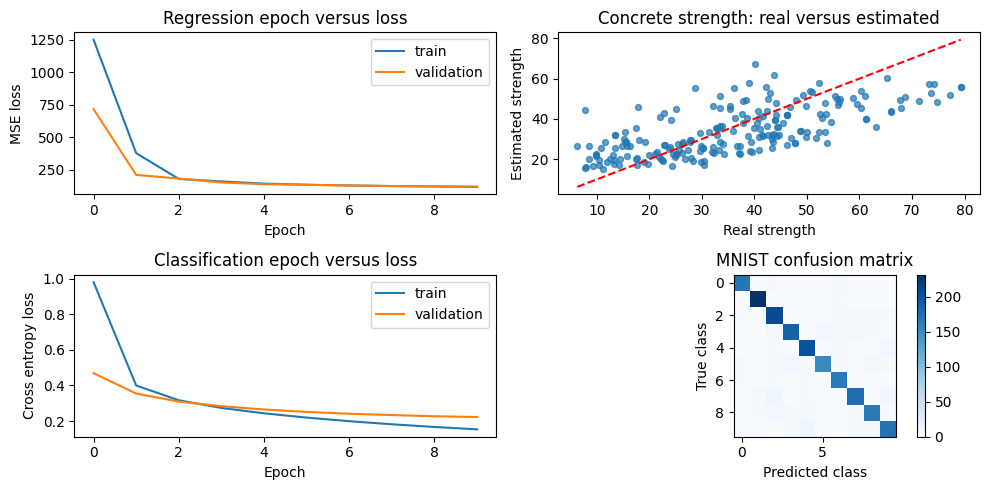

In [17]:
#@title Python Code - Regression Classification Workflow

# Sequential models solve two task types.
# This notebook compares regression and classification.
# Civil engineering examples guide each step.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Download the concrete strength file.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Load the regression dataset.
concrete_df = pd.read_excel("./Concrete_Data.xls")

# Separate features and target.
X_reg = concrete_df.iloc[:, :-1].to_numpy(dtype="float32")
y_reg = concrete_df.iloc[:, -1].to_numpy(dtype="float32")

# Build a simple train split.
reg_count = len(X_reg)
reg_index = np.arange(reg_count)
np.random.shuffle(reg_index)

# Slice train and test indices.
reg_cut = int(reg_count * 0.8)
reg_train_idx = reg_index[:reg_cut]
reg_test_idx = reg_index[reg_cut:]

# Create train and test arrays.
X_reg_train = X_reg[reg_train_idx]
X_reg_test = X_reg[reg_test_idx]
y_reg_train = y_reg[reg_train_idx]
y_reg_test = y_reg[reg_test_idx]

# Standardize regression features safely.
reg_mean = X_reg_train.mean(axis=0)
reg_std = X_reg_train.std(axis=0)
reg_std[reg_std == 0] = 1.0

# Apply the scaling values.
X_reg_train = (X_reg_train - reg_mean) / reg_std
X_reg_test = (X_reg_test - reg_mean) / reg_std

# Define a Sequential regression model.
reg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_reg_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile for continuous prediction.
reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss="mse",
    metrics=["mae"]
)

# Train the regression model quietly.
reg_history = reg_model.fit(
    X_reg_train,
    y_reg_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=0
)

# Predict concrete strength values.
reg_pred = reg_model.predict(X_reg_test, verbose=0).flatten()
reg_mae = mean_absolute_error(y_reg_test, reg_pred)

# Load the image classification dataset.
mnist = tf.keras.datasets.mnist
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist.load_data()

# Use small subsets for speed.
train_n = 12000
test_n = 2000
x_train = x_train_all[:train_n]
y_train = y_train_all[:train_n]
x_test = x_test_all[:test_n]
y_test = y_test_all[:test_n]

# Scale image values to zero and one.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One hot encode class labels.
y_train_hot = tf.keras.utils.to_categorical(y_train, 10)
y_test_hot = tf.keras.utils.to_categorical(y_test, 10)

# Define a Sequential classification model.
cls_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile for class probabilities.
cls_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the classification model quietly.
cls_history = cls_model.fit(
    x_train,
    y_train_hot,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=0
)

# Predict digit classes.
cls_prob = cls_model.predict(x_test, verbose=0)
y_pred = np.argmax(cls_prob, axis=1)
cls_acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Print short workflow summary.
print("Regression output layer: one neuron, linear activation.")
print("Regression loss with Adam: mse for strength prediction.")
print("Regression test MAE:", round(float(reg_mae), 3))
print("Classification output: ten neurons, softmax activation.")
print("Classification loss with Adam: categorical crossentropy.")
print("Classification test accuracy:", round(float(cls_acc), 3))

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

# Plot regression training losses.
axes[0, 0].plot(reg_history.history["loss"], label="train")
axes[0, 0].plot(reg_history.history["val_loss"], label="validation")
axes[0, 0].set_title("Regression epoch versus loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE loss")
axes[0, 0].legend()

# Plot real versus estimated strengths.
axes[0, 1].scatter(y_reg_test, reg_pred, s=18, alpha=0.7)
axes[0, 1].set_title("Concrete strength: real versus estimated")
axes[0, 1].set_xlabel("Real strength")
axes[0, 1].set_ylabel("Estimated strength")

# Add a reference diagonal.
reg_min = float(min(y_reg_test.min(), reg_pred.min()))
reg_max = float(max(y_reg_test.max(), reg_pred.max()))
axes[0, 1].plot([reg_min, reg_max], [reg_min, reg_max], "r--")

# Plot classification training losses.
axes[1, 0].plot(cls_history.history["loss"], label="train")
axes[1, 0].plot(cls_history.history["val_loss"], label="validation")
axes[1, 0].set_title("Classification epoch versus loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Cross entropy loss")
axes[1, 0].legend()

# Plot the confusion matrix.
image = axes[1, 1].imshow(cm, cmap="Blues")
axes[1, 1].set_title("MNIST confusion matrix")
axes[1, 1].set_xlabel("Predicted class")
axes[1, 1].set_ylabel("True class")
fig.colorbar(image, ax=axes[1, 1])

# Tighten layout and show figure.
plt.tight_layout()
plt.show()



## **2. CNN Training Components**

### **2.1. Encoding and Losses**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_02_01.jpg?v=1774648321" width="250">



>* Labels must match network output format.
>* One-hot encoding enables trainable class comparisons.

>* Cross entropy fits multi-class CNN classification.
>* Regression uses error losses, not cross entropy.

>* Wrong encoding or loss misguides training.
>* Correct choices improve reliability and interpretability.



TensorFlow version: 2.21.0
Training device: CPU
Example integer label: 6
One hot label shape: (10,)
Cross entropy compares predicted probabilities with true targets.
Categorical cross entropy is that idea for many classes.
Test accuracy: 0.518


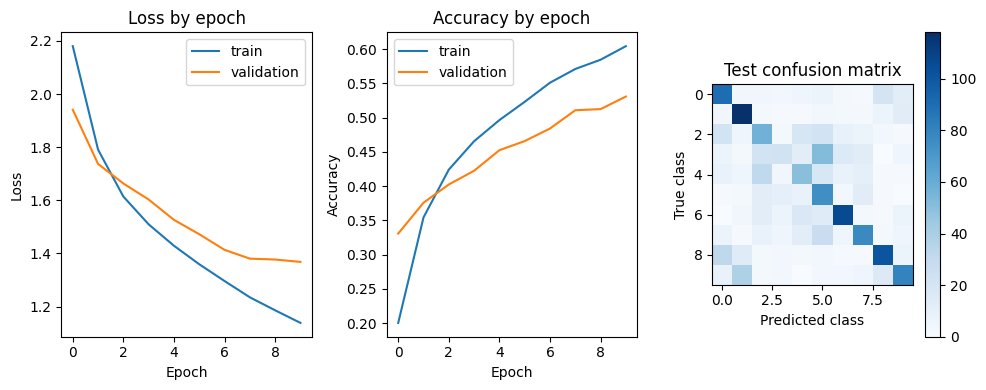

In [18]:
#@title Python Code - Encoding and Losses

# CIFAR ten shows image label encoding.
# Categorical loss fits one hot labels.
# This example stays small and clear.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)
print("TensorFlow version:", tf.__version__)

# Check available training device.
gpu_list = tf.config.list_physical_devices("GPU")
if len(gpu_list) > 0:
    device_name = "GPU"
else:
    device_name = "CPU"

print("Training device:", device_name)

# Load CIFAR ten image data.
(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.cifar10.load_data()
)

# Keep a small subset for speed.
train_count = 6000
test_count = 1500
train_images = train_images[:train_count]
train_labels = train_labels[:train_count]

test_images = test_images[:test_count]
test_labels = test_labels[:test_count]

# Scale pixel values to zero one.
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Flatten label arrays safely.
train_labels = train_labels.reshape(-1)
test_labels = test_labels.reshape(-1)

# Confirm image and label sizes.
assert train_images.shape[0] == train_labels.shape[0]
assert test_images.shape[0] == test_labels.shape[0]

# Convert integers into one hot vectors.
num_classes = 10
train_labels_hot = tf.keras.utils.to_categorical(
    train_labels,
    num_classes=num_classes
)

test_labels_hot = tf.keras.utils.to_categorical(
    test_labels,
    num_classes=num_classes
)

# Show one label before encoding.
print("Example integer label:", int(train_labels[0]))

# Show one hot vector shape.
print("One hot label shape:", train_labels_hot[0].shape)

# Explain cross entropy simply.
print("Cross entropy compares predicted probabilities with true targets.")
print("Categorical cross entropy is that idea for many classes.")

# Build a small convolutional classifier.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

# Compile using categorical cross entropy.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train quietly with validation split.
history = model.fit(
    train_images,
    train_labels_hot,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

# Predict class probabilities on test data.
test_probabilities = model.predict(test_images, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)

# Compute test accuracy and confusion matrix.
test_accuracy = accuracy_score(test_labels, test_predictions)
cm = confusion_matrix(test_labels, test_predictions)
print("Test accuracy:", round(float(test_accuracy), 4))

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Plot training and validation loss.
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="validation")
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot training and validation accuracy.
axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Plot the test confusion matrix.
image_plot = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Test confusion matrix")
axes[2].set_xlabel("Predicted class")
axes[2].set_ylabel("True class")
fig.colorbar(image_plot, ax=axes[2])

# Tight layout improves readability.
plt.tight_layout()
plt.show()



### **2.2. Regularization and Normalization**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_02_02.jpg?v=1774648358" width="250">



>* Regularization reduces overfitting to noisy details.
>* Normalization stabilizes training and improves generalization.

>* Dropout spreads learning across multiple features.
>* Balance regularization to avoid underlearning or overfitting.

>* BatchNormalization stabilizes activations for faster training.
>* With regularization, it improves reliable generalization.



TensorFlow version: 2.21.0
Training device: CPU
Train shape: (12000, 28, 28, 1) Test shape: (2000, 28, 28, 1)
Sparse cross entropy uses integer labels directly.
Categorical cross entropy needs one hot labels.
BatchNormalization stabilizes activations during training.
Dropout reduces overfitting by hiding random units.
Test loss: 0.0984
Test accuracy: 0.9665


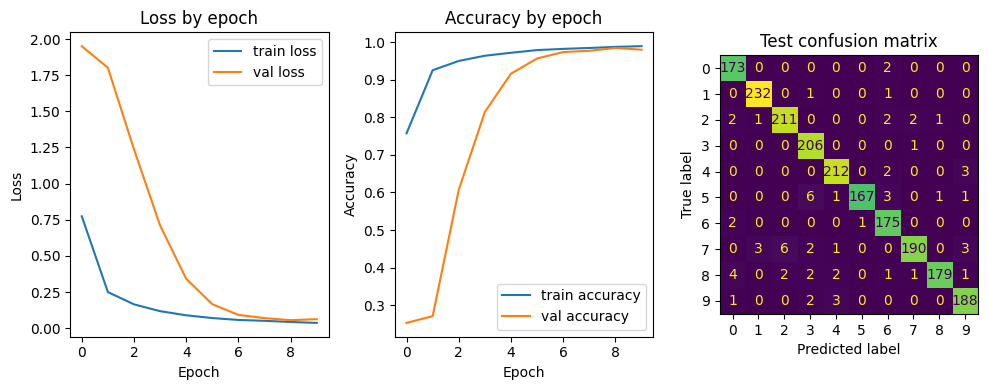

In [19]:
#@title Python Code - Regularization and Normalization

# CNN regularization improves robust image learning.
# Batch normalization stabilizes hidden activation scales.
# MNIST mimics defect image classification basics.

# Import beginner friendly libraries.
import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

# Import plotting and metrics tools.
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Set deterministic random seeds.
np.random.seed(7)
tf.random.set_seed(7)
print("TensorFlow version:", tf.__version__)

# Detect available training device.
gpu_list = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpu_list) > 0 else "CPU"
print("Training device:", device_name)

# Load MNIST handwritten image data.
mnist_data = tf.keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = mnist_data

# Use smaller subsets for speed.
x_train = x_train[:12000]
y_train = y_train[:12000]
x_test = x_test[:2000]
y_test = y_test[:2000]

# Validate basic dataset shapes.
assert x_train.ndim == 3 and x_test.ndim == 3
assert len(x_train) == len(y_train)
assert len(x_test) == len(y_test)

# Scale pixel values safely.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN.
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

# Build a small CNN classifier.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile with sparse cross entropy.
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Explain key training ideas briefly.
print("Sparse cross entropy uses integer labels directly.")
print("Categorical cross entropy needs one hot labels.")
print("BatchNormalization stabilizes activations during training.")
print("Dropout reduces overfitting by hiding random units.")

# Train quietly with validation split.
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Evaluate quietly on test data.
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", round(float(test_loss), 4))
print("Test accuracy:", round(float(test_acc), 4))

# Predict test classes quietly.
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Build confusion matrix values.
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm)
assert cm_df.shape == (10, 10)

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Plot training and validation loss.
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot training and validation accuracy.
axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Plot the test confusion matrix.
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(ax=axes[2], colorbar=False)
axes[2].set_title("Test confusion matrix")
plt.tight_layout()
plt.show()



### **2.3. Training Component Choices**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_02_03.jpg?v=1774648392" width="250">



>* Choose 1D or 2D by data shape.
>* Pooling and padding preserve important features.

>* Layer depth and activations match task complexity.
>* Reshaping and flattening guide prediction flow.

>* Balance accuracy, cost, and model simplicity.
>* Filter and pooling choices shape robustness.



TensorFlow: 2.21.0 GPU: False
Workflow 1 val accuracy: 0.9645
Workflow 2 val accuracy: 0.977
Selected model: integer labels plus sparse crossentropy
BatchNormalization stabilizes learning between layers.
Dropout reduces overfitting by randomly hiding units.


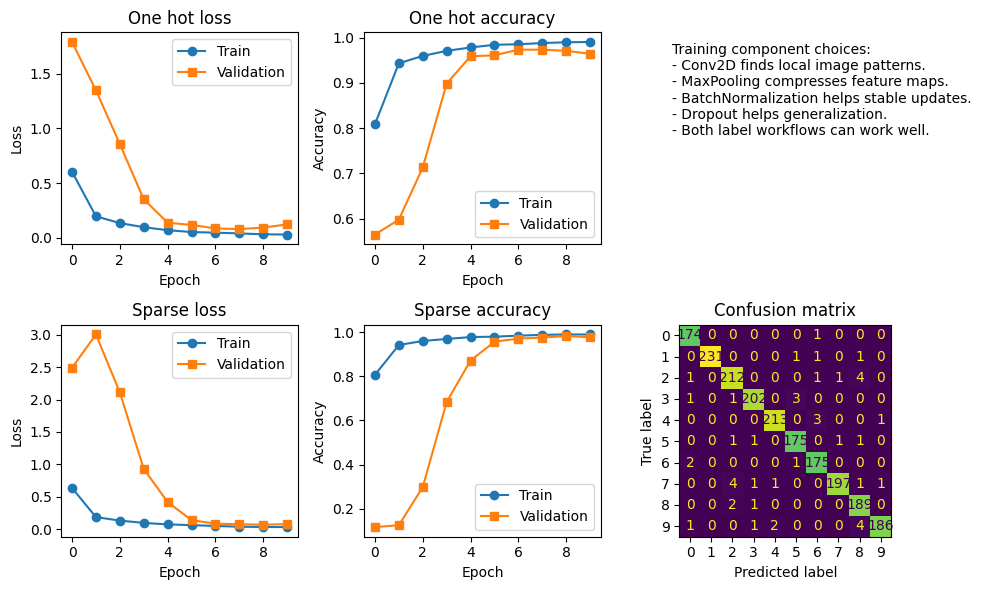

In [20]:
#@title Python Code - Training Component Choices

# Beginner CNN training choices for image classification.
# Civil engineering students compare two label workflows.
# BatchNormalization and Dropout improve stable generalization.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Set deterministic seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Show framework version and device summary.
gpu_flag = len(tf.config.list_physical_devices("GPU")) > 0
print("TensorFlow:", tf.__version__, "GPU:", gpu_flag)

# Load MNIST handwritten image data.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

# Use smaller subsets for quick teaching runs.
train_n = 12000
test_n = 2000
train_x = train_x[:train_n]
train_y = train_y[:train_n]

test_x = test_x[:test_n]
test_y = test_y[:test_n]

# Normalize images and add channel dimension.
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0
train_x = np.expand_dims(train_x, axis=-1)
test_x = np.expand_dims(test_x, axis=-1)

# Validate image shapes before training.
assert train_x.shape[1:] == (28, 28, 1)
assert test_x.shape[1:] == (28, 28, 1)

# Create one hot labels for workflow one.
train_y_hot = tf.keras.utils.to_categorical(train_y, 10)
test_y_hot = tf.keras.utils.to_categorical(test_y, 10)

# Build a small CNN model.
def make_model():

    # Stack convolution and pooling layers.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.MaxPooling2D(pool_size=2),
        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=2),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model

# Train workflow using one hot labels.
model_cat = make_model()
model_cat.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_cat = model_cat.fit(
    train_x,
    train_y_hot,
    validation_data=(test_x, test_y_hot),
    epochs=10,
    batch_size=128,
    verbose=0
)

# Train workflow using integer labels.
model_sparse = make_model()
model_sparse.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_sparse = model_sparse.fit(
    train_x,
    train_y,
    validation_data=(test_x, test_y),
    epochs=10,
    batch_size=128,
    verbose=0
)

# Compare final validation accuracy values.
cat_acc = history_cat.history["val_accuracy"][-1]
sparse_acc = history_sparse.history["val_accuracy"][-1]

# Select the better final model.
if cat_acc >= sparse_acc:
    best_name = "one hot plus categorical crossentropy"
    best_model = model_cat
else:
    best_name = "integer labels plus sparse crossentropy"
    best_model = model_sparse

# Print short teaching summary lines.
print("Workflow 1 val accuracy:", round(float(cat_acc), 4))
print("Workflow 2 val accuracy:", round(float(sparse_acc), 4))
print("Selected model:", best_name)
print("BatchNormalization stabilizes learning between layers.")
print("Dropout reduces overfitting by randomly hiding units.")

# Predict classes for confusion matrix.
pred_probs = best_model.predict(test_x, verbose=0)
pred_y = np.argmax(pred_probs, axis=1)
cm = confusion_matrix(test_y, pred_y)

# Create one figure with all required plots.
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Plot loss for one hot workflow.
axes[0, 0].plot(history_cat.history["loss"], marker="o")
axes[0, 0].plot(history_cat.history["val_loss"], marker="s")
axes[0, 0].set_title("One hot loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(["Train", "Validation"])

# Plot accuracy for one hot workflow.
axes[0, 1].plot(history_cat.history["accuracy"], marker="o")
axes[0, 1].plot(history_cat.history["val_accuracy"], marker="s")
axes[0, 1].set_title("One hot accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(["Train", "Validation"])

# Add short design note.
axes[0, 2].axis("off")
axes[0, 2].text(
    0.02,
    0.95,
    "Training component choices:\n"
    "- Conv2D finds local image patterns.\n"
    "- MaxPooling compresses feature maps.\n"
    "- BatchNormalization helps stable updates.\n"
    "- Dropout helps generalization.\n"
    "- Both label workflows can work well.",
    va="top",
    fontsize=10
)

# Plot loss for sparse workflow.
axes[1, 0].plot(history_sparse.history["loss"], marker="o")
axes[1, 0].plot(history_sparse.history["val_loss"], marker="s")
axes[1, 0].set_title("Sparse loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(["Train", "Validation"])

# Plot accuracy for sparse workflow.
axes[1, 1].plot(history_sparse.history["accuracy"], marker="o")
axes[1, 1].plot(history_sparse.history["val_accuracy"], marker="s")
axes[1, 1].set_title("Sparse accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(["Train", "Validation"])

# Plot confusion matrix for selected model.
ConfusionMatrixDisplay(cm).plot(ax=axes[1, 2], colorbar=False)
axes[1, 2].set_title("Confusion matrix")

# Tight layout improves readability.
plt.tight_layout()
plt.show()



## **3. CNN Training Methods**

### **3.1. CNN Pooling Padding**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_03_01.jpg?v=1774648442" width="250">



>* Pooling reduces feature size and computation.
>* Max or average pooling improves robustness.

>* Padding preserves edges and output size.
>* It supports deeper, context-aware convolutions.

>* Balance pooling and padding for robust learning.
>* They affect detail, efficiency, and generalization.



TensorFlow version: 2.21.0
Training device: CPU
1D input and pooled shapes: (1, 12, 4) (1, 6, 4) (1, 6, 4)
1D validation samples: 178
2D valid and same shapes: (1, 26, 26, 4) (1, 28, 28, 4)
2D max and avg shapes: (1, 14, 14, 4) (1, 14, 14, 4)
2D test samples: 2000


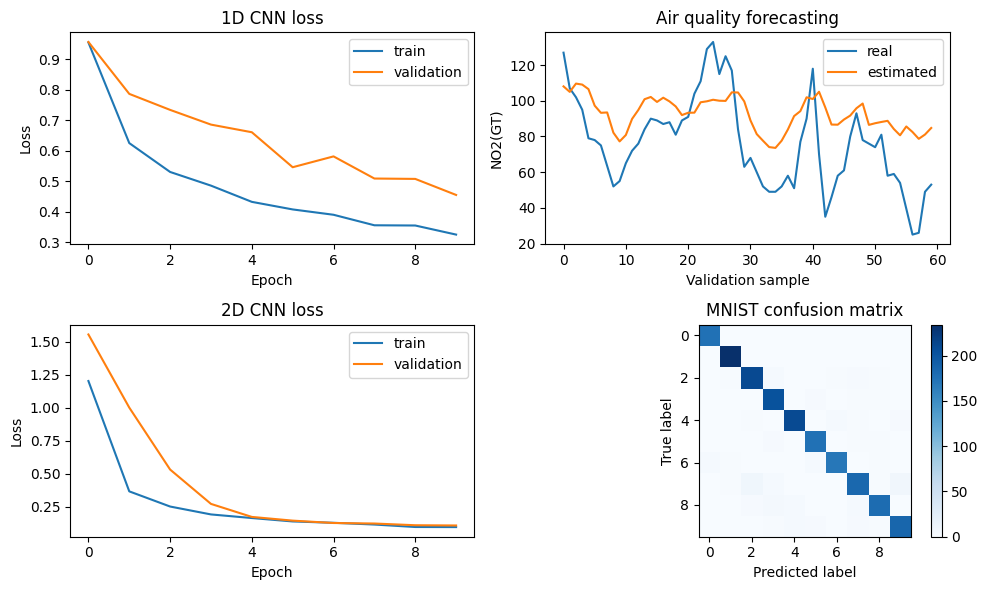

In [21]:
#@title Python Code - CNN Pooling Padding

# Pooling and padding shape convolution learning.
# This notebook shows simple civil examples.
# Small models keep runtime beginner friendly.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import random
import zipfile
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import confusion_matrix

# Set deterministic seeds carefully.
np.random.seed(7)
random.seed(7)
tf.random.set_seed(7)
print("TensorFlow version:", tf.__version__)

# Detect available training device.
gpus = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpus) > 0 else "CPU"
print("Training device:", device_name)

# Download the air quality dataset.
get_ipython().system("wget -q -O AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip")
with zipfile.ZipFile("AirQualityUCI.zip", "r") as zf:
    zf.extractall("air_quality_data")

# Load the downloaded csv file.
air_path = os.path.join("air_quality_data", "AirQualityUCI.csv")
air_df = pd.read_csv(air_path, sep=";", decimal=",")
air_df = air_df.dropna(axis=1, how="all")
air_df = air_df.loc[:, ~air_df.columns.str.contains("^Unnamed")]

# Clean missing values and columns.
air_df = air_df.replace(-200, np.nan)
air_df = air_df.drop(columns=["Date", "Time"], errors="ignore")
air_df = air_df.apply(pd.to_numeric, errors="coerce")
air_df = air_df.interpolate(limit_direction="both")

# Keep a compact numeric subset.
air_df = air_df.dropna()
air_df = air_df.iloc[:900].copy()
feature_cols = ["CO(GT)", "PT08.S1(CO)", "NMHC(GT)", "C6H6(GT)"]
target_col = "NO2(GT)"

# Build simple time windows.
values_x = air_df[feature_cols].to_numpy(dtype="float32")
values_y = air_df[target_col].to_numpy(dtype="float32")
mean_x = values_x.mean(axis=0)
std_x = values_x.std(axis=0) + 1e-6

# Standardize the input features.
values_x = (values_x - mean_x) / std_x
mean_y = values_y.mean()
std_y = values_y.std() + 1e-6
values_y = (values_y - mean_y) / std_y

# Create supervised sequence samples.
window = 12
x_seq = []
y_seq = []
for i in range(len(values_x) - window):
    x_seq.append(values_x[i:i + window])
    y_seq.append(values_y[i + window])

# Convert lists into arrays.
x_seq = np.array(x_seq, dtype="float32")
y_seq = np.array(y_seq, dtype="float32")
if len(x_seq.shape) != 3:
    raise ValueError("Unexpected 1D CNN input shape")

# Split train and validation sets.
split_1d = int(0.8 * len(x_seq))
x1_train = x_seq[:split_1d]
y1_train = y_seq[:split_1d]
x1_val = x_seq[split_1d:]
y1_val = y_seq[split_1d:]

# Show pooling output shapes.
sample_1d = tf.constant(x1_train[:1])
max_1d = tf.keras.layers.MaxPooling1D(pool_size=2)(sample_1d)
avg_1d = tf.keras.layers.AveragePooling1D(pool_size=2)(sample_1d)
print("1D input and pooled shapes:", sample_1d.shape, max_1d.shape, avg_1d.shape)

# Build a small 1D CNN model.
model_1d = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(window, len(feature_cols))),
    tf.keras.layers.Conv1D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.AveragePooling1D(pool_size=2),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile the 1D regression model.
model_1d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

# Train the 1D CNN quietly.
history_1d = model_1d.fit(
    x1_train,
    y1_train,
    validation_data=(x1_val, y1_val),
    epochs=10,
    batch_size=32,
    verbose=0
)

# Predict and restore original scale.
pred_1d = model_1d.predict(x1_val, verbose=0).reshape(-1)
real_1d = y1_val * std_y + mean_y
est_1d = pred_1d * std_y + mean_y
print("1D validation samples:", len(real_1d))

# Load a small MNIST subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train[:8000].astype("float32") / 255.0
x_test = x_test[:2000].astype("float32") / 255.0
y_train = y_train[:8000]
y_test = y_test[:2000]

# Add channel dimension and encode labels.
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

# Compare valid and same padding.
sample_2d = tf.constant(x_train[:1])
valid_out = tf.keras.layers.Conv2D(4, 3, padding="valid")(sample_2d)
same_out = tf.keras.layers.Conv2D(4, 3, padding="same")(sample_2d)
print("2D valid and same shapes:", valid_out.shape, same_out.shape)

# Show 2D pooling output shapes.
max_2d = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(same_out)
avg_2d = tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(same_out)
print("2D max and avg shapes:", max_2d.shape, avg_2d.shape)

# Build a small 2D CNN model.
model_2d = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(8, 3, padding="same", activation="relu"),
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the 2D classification model.
model_2d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the 2D CNN quietly.
history_2d = model_2d.fit(
    x_train,
    y_train_oh,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=0
)

# Predict classes and confusion matrix.
pred_probs = model_2d.predict(x_test, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
cm = confusion_matrix(y_test, pred_labels)
print("2D test samples:", len(y_test))

# Create one compact teaching figure.
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Plot 1D training and validation loss.
axes[0, 0].plot(history_1d.history["loss"], label="train")
axes[0, 0].plot(history_1d.history["val_loss"], label="validation")
axes[0, 0].set_title("1D CNN loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Plot real versus estimated values.
show_n = min(60, len(real_1d))
axes[0, 1].plot(real_1d[:show_n], label="real")
axes[0, 1].plot(est_1d[:show_n], label="estimated")
axes[0, 1].set_title("Air quality forecasting")
axes[0, 1].set_xlabel("Validation sample")
axes[0, 1].set_ylabel("NO2(GT)")
axes[0, 1].legend()

# Plot 2D training and validation loss.
axes[1, 0].plot(history_2d.history["loss"], label="train")
axes[1, 0].plot(history_2d.history["val_loss"], label="validation")
axes[1, 0].set_title("2D CNN loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Plot the confusion matrix.
image = axes[1, 1].imshow(cm, cmap="Blues")
axes[1, 1].set_title("MNIST confusion matrix")
axes[1, 1].set_xlabel("Predicted label")
axes[1, 1].set_ylabel("True label")
fig.colorbar(image, ax=axes[1, 1], fraction=0.046)

# Finish the figure neatly.
plt.tight_layout()
plt.show()



### **3.2. Tensor Preparation**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_03_02.jpg?v=1774648504" width="250">



>* Prepare tensors with correct shapes and scaling.
>* Match sequence, image, and label formats.

>* Normalize inputs for stable, accurate training.
>* Encode labels to match loss outputs.

>* Split data carefully to prevent leakage.
>* Batch tensors well for reliable training.



TensorFlow version: 2.21.0
Training device: CPU
Air table shape: (256, 8)
Conv1D tensor shape: (256, 8, 1)
CIFAR10 image shape: (2000, 32, 32, 3)
One hot label shape: (2000, 10)


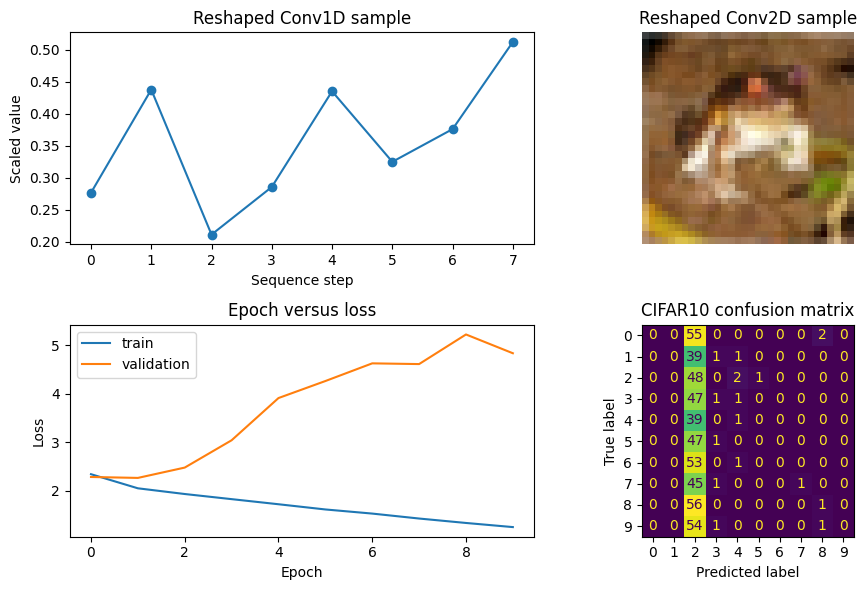

Flatten output shape: (1, 256)


In [22]:
#@title Python Code - Tensor Preparation

# Tensor preparation supports stable convolution model training.
# This notebook shows reshaping and encoding basics.
# Civil engineering examples use small safe datasets.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import random
import zipfile
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Set deterministic seeds for repeatable results.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Print one short framework version line.
print("TensorFlow version:", tf.__version__)

# Check whether GPU is available.
device_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("Training device:", device_name)

# Download the air quality dataset.
!wget -q -O AirQualityUCI.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip

# Extract the downloaded zip file.
with zipfile.ZipFile("AirQualityUCI.zip", "r") as zip_ref:
    zip_ref.extractall("air_quality_data")

# Load the air quality table.
air_path = "air_quality_data/AirQualityUCI.csv"
air_df = pd.read_csv(air_path, sep=";", decimal=",")

# Keep useful columns and clean values.
air_df = air_df.dropna(axis=1, how="all")
air_df = air_df.loc[:, air_df.columns != "Unnamed: 15"]
air_df = air_df.loc[:, air_df.columns != "Unnamed: 16"]

# Replace missing markers with NaN.
air_df = air_df.replace(-200, np.nan)
air_df = air_df.select_dtypes(include=[np.number])

# Fill missing values with medians.
air_df = air_df.fillna(air_df.median(numeric_only=True))
air_df = air_df.iloc[:256, :8].copy()

# Normalize tabular values for Conv1D.
air_values = air_df.to_numpy(dtype=np.float32)
air_min = air_values.min(axis=0, keepdims=True)
air_max = air_values.max(axis=0, keepdims=True)
air_scaled = (air_values - air_min) / (air_max - air_min + 1e-6)

# Reshape tabular rows into 1D tensors.
air_1d = air_scaled.reshape(air_scaled.shape[0], air_scaled.shape[1], 1)

# Validate the Conv1D input shape.
assert air_1d.ndim == 3
assert air_1d.shape[2] == 1

# Load a small CIFAR10 subset.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train[:2000].astype("float32") / 255.0
x_test = x_test[:500].astype("float32") / 255.0

# Prepare one hot encoded labels.
y_train = y_train[:2000].reshape(-1)
y_test = y_test[:500].reshape(-1)
y_train_hot = tf.keras.utils.to_categorical(y_train, 10)
y_test_hot = tf.keras.utils.to_categorical(y_test, 10)

# Validate the Conv2D input shape.
assert x_train.ndim == 4
assert x_train.shape[1:] == (32, 32, 3)

# Build a tiny Conv1D demonstration model.
conv1d_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(air_1d.shape[1], 1)),
    tf.keras.layers.Reshape((air_1d.shape[1], 1)),
    tf.keras.layers.Conv1D(8, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(8, activation="relu")
])

# Build a small Conv2D image classifier.
conv2d_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Reshape((32, 32, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile the image model with Adam.
conv2d_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train silently for a few epochs.
history = conv2d_model.fit(
    x_train,
    y_train_hot,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=0
)

# Predict classes for the confusion matrix.
y_prob = conv2d_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
cm = confusion_matrix(y_test, y_pred)

# Print short shape summaries.
print("Air table shape:", air_scaled.shape)
print("Conv1D tensor shape:", air_1d.shape)
print("CIFAR10 image shape:", x_train.shape)
print("One hot label shape:", y_train_hot.shape)

# Create one figure with all required plots.
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Plot one reshaped 1D sample.
axes[0, 0].plot(air_1d[0, :, 0], marker="o")
axes[0, 0].set_title("Reshaped Conv1D sample")
axes[0, 0].set_xlabel("Sequence step")
axes[0, 0].set_ylabel("Scaled value")

# Plot one reshaped 2D image sample.
axes[0, 1].imshow(x_train[0])
axes[0, 1].set_title("Reshaped Conv2D sample")
axes[0, 1].axis("off")

# Plot epoch versus loss curves.
axes[1, 0].plot(history.history["loss"], label="train")
axes[1, 0].plot(history.history["val_loss"], label="validation")
axes[1, 0].set_title("Epoch versus loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

# Plot the confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("CIFAR10 confusion matrix")

# Tight layout keeps the figure readable.
plt.tight_layout()
plt.show()

# Show how Flatten changes dimensions.
feature_map = tf.ones((1, 8, 8, 4))
flat_output = tf.keras.layers.Flatten()(feature_map)
print("Flatten output shape:", tuple(flat_output.shape))



### **3.3. Training Metrics**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_06/Lecture_A/image_03_03.jpg?v=1774648547" width="250">



>* Metrics connect loss to practical performance.
>* Compare training and validation for generalization.

>* Cross entropy tracks confidence, not just correctness.
>* Falling loss can improve calibration and decisions.

>* Compare training and validation metrics together.
>* Consistent trends indicate generalization and readiness.



TensorFlow: 2.21.0
sklearn: 1.8.0
GPU available: False
MNIST test accuracy: 0.9715
Concrete test MAE: 7.923
Concrete test R2: 0.615


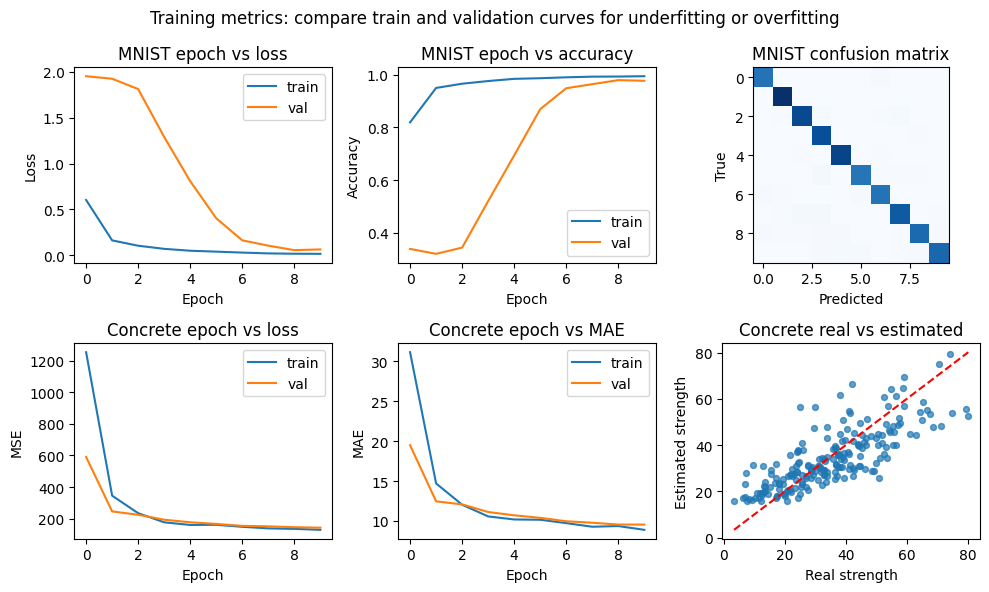

In [23]:
#@title Python Code - Training Metrics

# This notebook studies training metrics carefully.
# We compare CNN and dense models.
# Civil engineering examples guide interpretation.

import os, warnings; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'; warnings.filterwarnings('ignore')
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf; tf.get_logger().setLevel('ERROR')
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)
tf.random.set_seed(7)

# Show short version information.
print("TensorFlow:", tf.__version__)
print("sklearn: 1.8.0")

# Check available training device.
gpu_list = tf.config.list_physical_devices("GPU")
use_gpu = len(gpu_list) > 0
print("GPU available:", use_gpu)

# Load MNIST image classification data.
mnist = tf.keras.datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

# Keep a small subset for speed.
train_x = train_x[:12000]
train_y = train_y[:12000]
test_x = test_x[:2000]
test_y = test_y[:2000]

# Scale images and add channel.
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0
train_x = np.expand_dims(train_x, -1)
test_x = np.expand_dims(test_x, -1)

# One hot encode labels.
num_classes = 10
train_y_hot = tf.keras.utils.to_categorical(train_y, num_classes)
test_y_hot = tf.keras.utils.to_categorical(test_y, num_classes)

# Build a small CNN model.
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile with Adam and cross entropy.
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train silently with validation split.
cnn_history = cnn_model.fit(
    train_x,
    train_y_hot,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Predict and score MNIST test data.
cnn_prob = cnn_model.predict(test_x, verbose=0)
cnn_pred = np.argmax(cnn_prob, axis=1)
mnist_acc = accuracy_score(test_y, cnn_pred)
mnist_cm = confusion_matrix(test_y, cnn_pred)

# Download concrete strength dataset.
!wget -q -O ./Concrete_Data.xls https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Read the downloaded spreadsheet.
concrete_df = pd.read_excel("./Concrete_Data.xls")
concrete_df.columns = [str(col).strip() for col in concrete_df.columns]

# Prepare regression inputs and target.
concrete_x = concrete_df.iloc[:, :-1].astype("float32").values
concrete_y = concrete_df.iloc[:, -1].astype("float32").values

# Split concrete data safely.
train_cx, test_cx, train_cy, test_cy = train_test_split(
    concrete_x,
    concrete_y,
    test_size=0.2,
    random_state=7
)

# Standardize using training statistics.
mean_cx = train_cx.mean(axis=0)
std_cx = train_cx.std(axis=0) + 1e-6
train_cx = (train_cx - mean_cx) / std_cx
test_cx = (test_cx - mean_cx) / std_cx

# Build a dense baseline regressor.
reg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(train_cx.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compile regression model simply.
reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

# Train regression model silently.
reg_history = reg_model.fit(
    train_cx,
    train_cy,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predict concrete test strengths.
reg_pred = reg_model.predict(test_cx, verbose=0).reshape(-1)
concrete_mae = mean_absolute_error(test_cy, reg_pred)
concrete_r2 = r2_score(test_cy, reg_pred)

# Print short metric summary.
print("MNIST test accuracy:", round(mnist_acc, 4))
print("Concrete test MAE:", round(concrete_mae, 3))
print("Concrete test R2:", round(concrete_r2, 3))

# Create one figure with all results.
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Plot MNIST loss curves.
axes[0, 0].plot(cnn_history.history["loss"], label="train")
axes[0, 0].plot(cnn_history.history["val_loss"], label="val")
axes[0, 0].set_title("MNIST epoch vs loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Plot MNIST accuracy curves.
axes[0, 1].plot(cnn_history.history["accuracy"], label="train")
axes[0, 1].plot(cnn_history.history["val_accuracy"], label="val")
axes[0, 1].set_title("MNIST epoch vs accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# Show MNIST confusion matrix.
axes[0, 2].imshow(mnist_cm, cmap="Blues")
axes[0, 2].set_title("MNIST confusion matrix")
axes[0, 2].set_xlabel("Predicted")
axes[0, 2].set_ylabel("True")

# Plot concrete loss curves.
axes[1, 0].plot(reg_history.history["loss"], label="train")
axes[1, 0].plot(reg_history.history["val_loss"], label="val")
axes[1, 0].set_title("Concrete epoch vs loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MSE")
axes[1, 0].legend()

# Plot concrete MAE curves.
axes[1, 1].plot(reg_history.history["mae"], label="train")
axes[1, 1].plot(reg_history.history["val_mae"], label="val")
axes[1, 1].set_title("Concrete epoch vs MAE")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].legend()

# Plot real versus estimated strengths.
axes[1, 2].scatter(test_cy, reg_pred, s=18, alpha=0.7)
line_min = float(min(test_cy.min(), reg_pred.min()))
line_max = float(max(test_cy.max(), reg_pred.max()))
axes[1, 2].plot([line_min, line_max], [line_min, line_max], "r--")
axes[1, 2].set_title("Concrete real vs estimated")
axes[1, 2].set_xlabel("Real strength")
axes[1, 2].set_ylabel("Estimated strength")

# Add one teaching summary.
fig.suptitle(
    "Training metrics: compare train and validation curves for underfitting or overfitting",
    fontsize=12
)
plt.tight_layout()
plt.show()



# <font color="#418FDE" size="6.5" uppercase>**TensorFlow Sequential & Convolutional Models**</font>


In this lecture, you learned to:
- Train TensorFlow Sequential models for CE prediction and classification tasks. 
- Construct convolutional neural networks using one- and two-dimensional convolution, pooling, padding, and more layers. 
- Apply methods such as Dropout, BatchNormalization, one-hot encoding, and more in TensorFlow models.  

In the next Lecture (Lecture B), we will go over 'Functional API & TensorFlow Architectures'